# Sales Forecassting Model

In [ ]:
# ===============================
# Import Libraries
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (14,6)

# Load Dataset

In [11]:
# Load Dataset
df = pd.read_csv(r"C:\Users\amans\Downloads\train.csv.zip")

# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [20]:
print(df["Order Date"].dtype)

object


In [22]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

In [23]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.to_csv("monthly_time_series.csv", index=False)

print("File Created Successfully")

File Created Successfully


In [24]:
# ===============================
# Load Monthly Sales Time Series
# ===============================

ts = pd.read_csv(
    "monthly_time_series.csv",
    index_col="Order Date",
    parse_dates=True
)

ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [25]:
print(ts.shape)

(48, 1)


# View Dataset

In [26]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2015-01-31 to 2018-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


# Monthly Sales Time Series

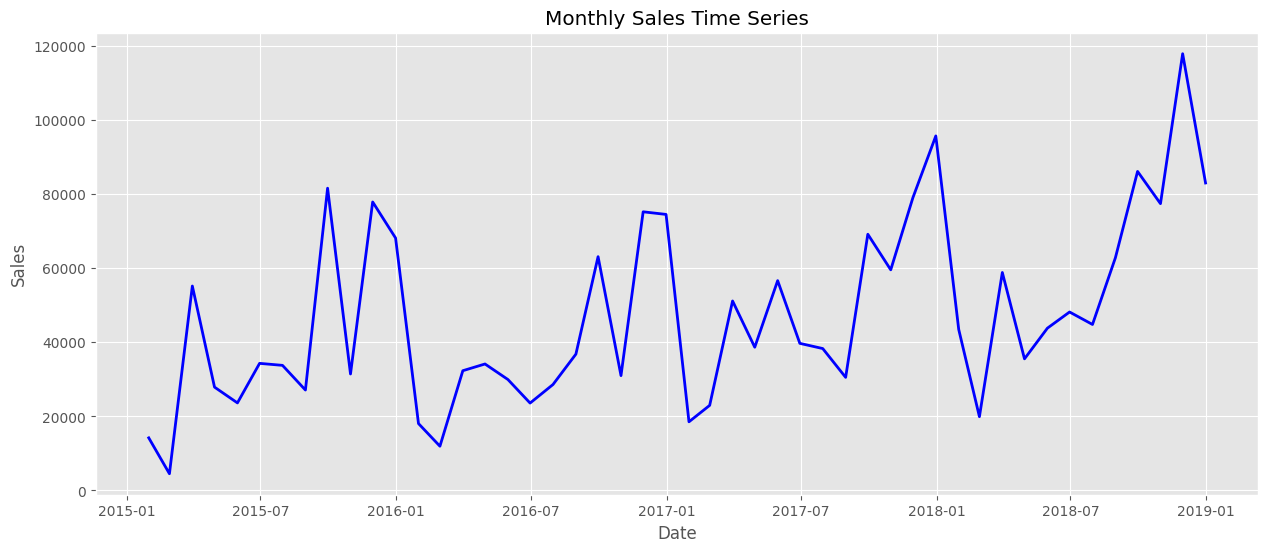

In [27]:
plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts["Sales"],
    linewidth=2,
    color="blue"
)

plt.title("Monthly Sales Time Series")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

# Train Test Split

In [28]:
# ===============================
# Train Test Split
# ===============================

train = ts.iloc[:-3]

test = ts.iloc[-3:]

print("Training Samples :", len(train))

print("Testing Samples :", len(test))

Training Samples : 45
Testing Samples : 3


In [30]:
print(train.tail())

                 Sales
Order Date            
2018-05-31  43825.9822
2018-06-30  48190.7277
2018-07-31  44825.1040
2018-08-31  62837.8480
2018-09-30  86152.8880


In [31]:
print(test)

                  Sales
Order Date             
2018-10-31   77448.1312
2018-11-30  117938.1550
2018-12-31   83030.3888


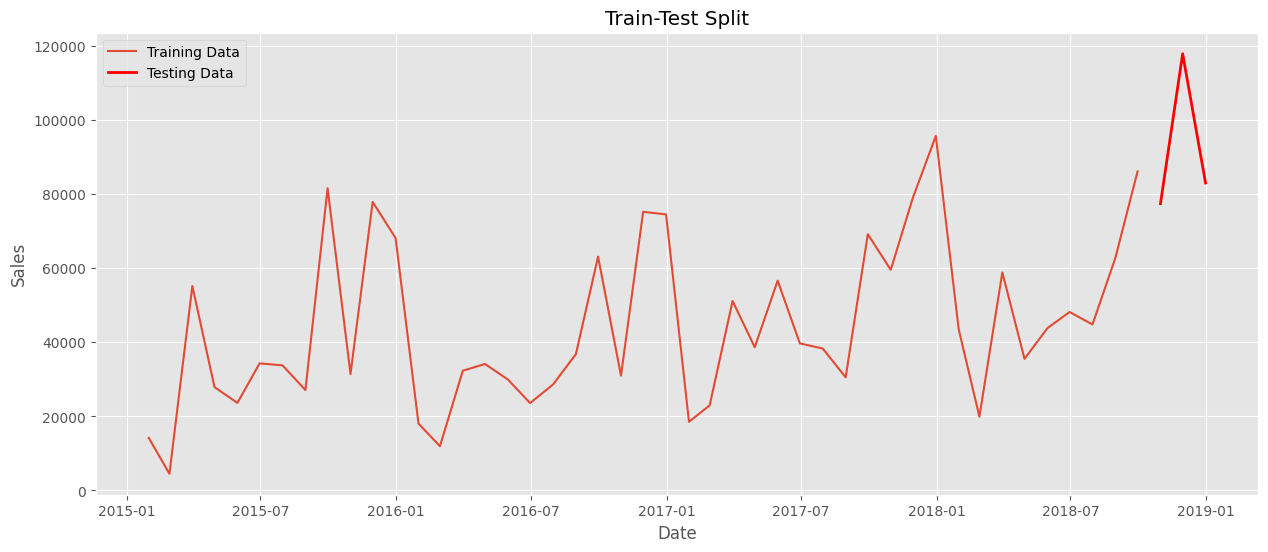

In [32]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["Sales"],
    color="red",
    linewidth=2,
    label="Testing Data"
)

plt.legend()

plt.title("Train-Test Split")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

# Sales Plot

<Figure size 1000x500 with 0 Axes>

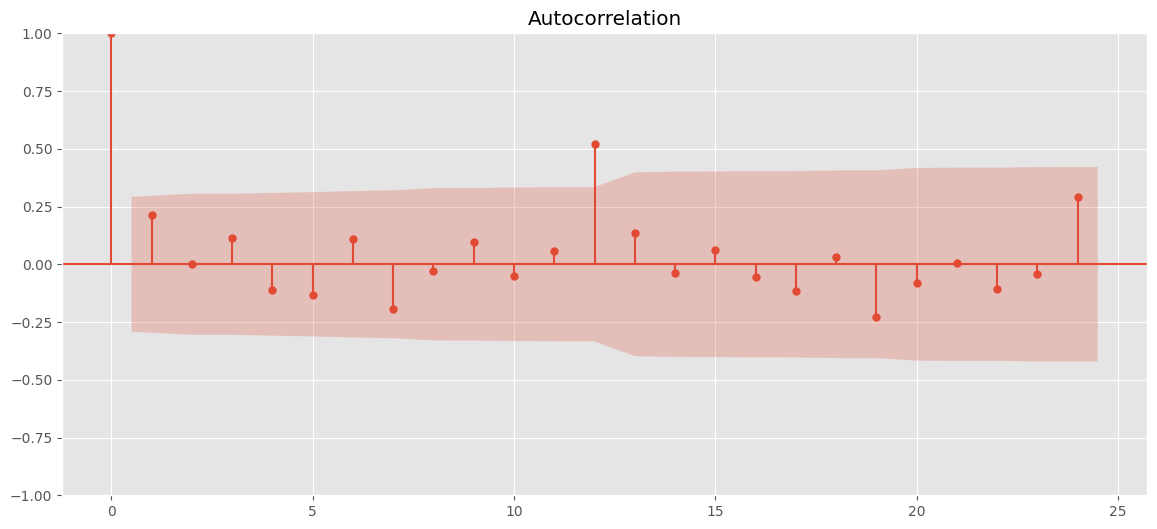

In [33]:
plt.figure(figsize=(10,5))

plot_acf(
    train["Sales"],
    lags=24
)

plt.show()

<Figure size 1000x500 with 0 Axes>

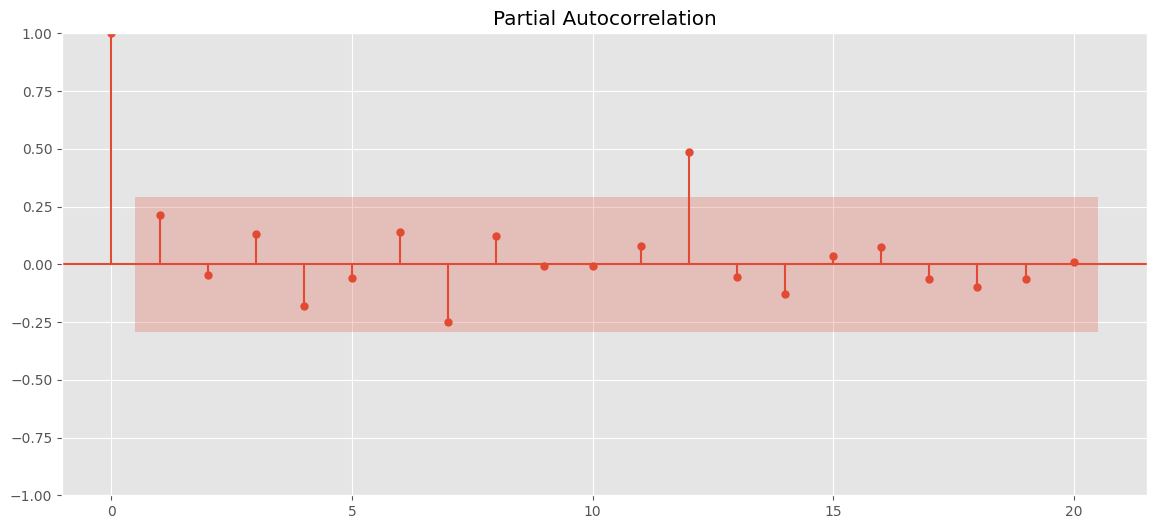

In [36]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))

plot_pacf(
    train["Sales"],
    lags=20,      # or 18, 15
    method="ywm"
)

plt.show()

In [37]:
# Non-seasonal parameters
p = 1
d = 1
q = 1

# Seasonal parameters
P = 1
D = 1
Q = 1

# Monthly seasonality
m = 12

In [38]:
train.describe()

,Sales
count,45.000000
mean,44069.335727
std,22198.269817
min,4519.892000
25%,28608.259000
50%,38320.783000
75%,59583.033000
max,95739.121000


In [39]:
# ===============================
# Import SARIMA Model
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [40]:
# ===============================
# Build SARIMA Model
# ===============================

sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [41]:
# ===============================
# Train Model
# ===============================

sarima_result = sarima_model.fit()

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


# Summary

In [42]:
sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Fri, 10 Jul 2026   AIC                            398.775
Time:                                    12:35:46   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261     -3.365      0.001      -1.391      -0.367
ar.S.L12      -0.2624      0.635     -0.413      0.680      -1.507       0.983
ma.S.L12      -0.3045      0.388     -0.784      0.433      -1.066       0.457
sigma2      1.822e+08   1.37e-09   1.33e+17      0.000    1.82e+08    1.82e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 1.29
Prob(Q):                              0.79   Prob(JB):                         0.52
Heteroskedasticity (H):               0.94   Skew:                             0.42
Prob(H) (two-sided):                  0.94   Kurtosis:                         1.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.03e+33. Standard errors may be unstable.
"""

# Residuals Head

In [43]:
residuals = sarima_result.resid

residuals.head()

Order Date
2015-01-31    14205.707000
2015-02-28   -10207.066601
2015-03-31    42872.527746
2015-04-30     4147.654176
2015-05-31     2305.117524
dtype: float64

# Sarima Residual

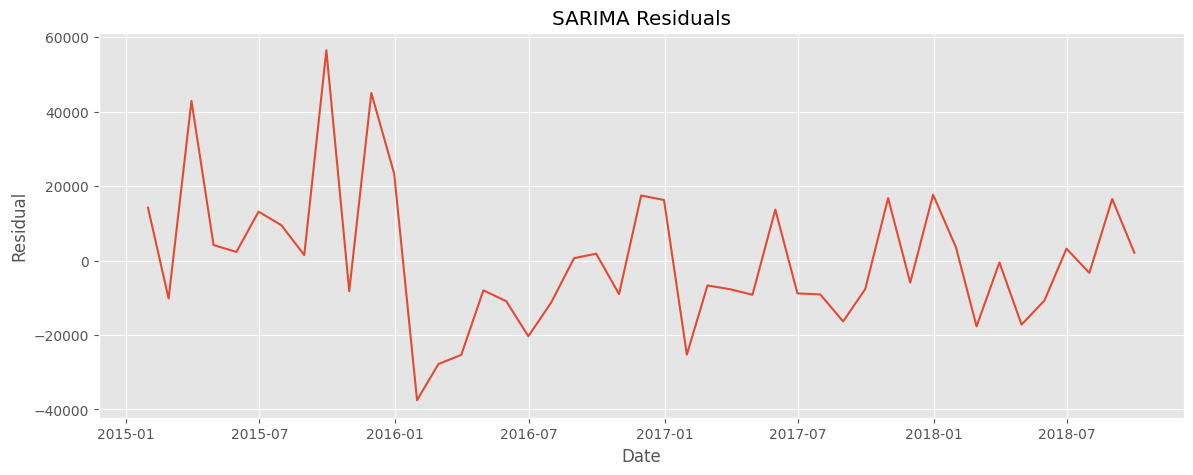

In [44]:
plt.figure(figsize=(14,5))

plt.plot(residuals)

plt.title("SARIMA Residuals")

plt.xlabel("Date")

plt.ylabel("Residual")

plt.grid(True)

plt.show()

# Distribution Of Residual

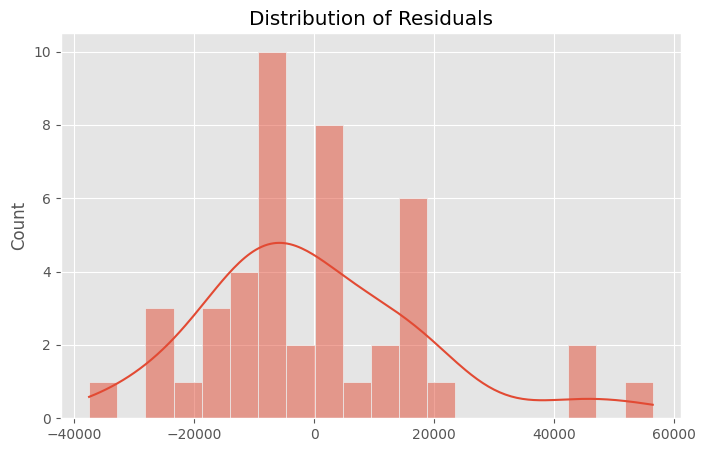

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title("Distribution of Residuals")

plt.show()

# Q-Q Plot Of Residual

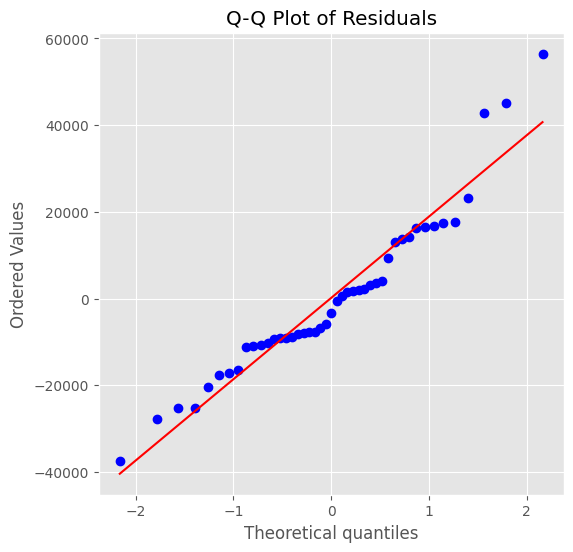

In [46]:
from scipy import stats

plt.figure(figsize=(6,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")

plt.show()

In [47]:
print(residuals.describe())

count       45.000000
mean       155.706342
std      18845.148140
min     -37524.212777
25%     -10207.066601
50%      -3319.256103
75%      13119.895031
max      56480.230000
dtype: float64


# Residual Mean

In [48]:
print("Residual Mean :", residuals.mean())

Residual Mean : 155.7063419507834


# Actual vs Fitted Sales

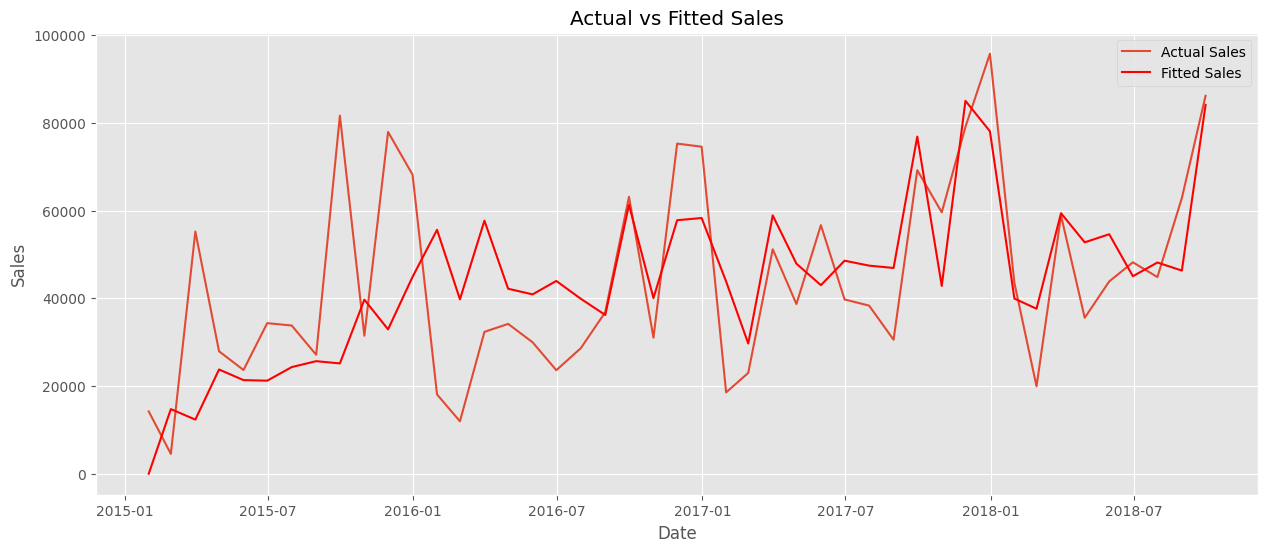

In [49]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Actual Sales"
)

plt.plot(
    train.index,
    sarima_result.fittedvalues,
    color="red",
    label="Fitted Sales"
)

plt.title("Actual vs Fitted Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [50]:
import pickle

with open("sarima_model.pkl", "wb") as file:
    pickle.dump(sarima_result, file)

print("SARIMA model saved successfully.")

SARIMA model saved successfully.


# Forecast Result

In [51]:
# ==========================================
# Forecast Next 3 Months
# ==========================================

forecast_result = sarima_result.get_forecast(steps=3)

forecast = forecast_result.predicted_mean

forecast

2018-10-31    60331.792094
2018-11-30    91458.220223
2018-12-31    97167.570942
Freq: ME, Name: predicted_mean, dtype: float64

# Confidence Interval

In [52]:
# ==========================================
# 95% Confidence Intervals
# ==========================================

confidence_interval = forecast_result.conf_int()

confidence_interval

,lower Sales,upper Sales
2018-10-31,33867.663903,86795.920285
2018-11-30,64294.739750,118621.700696
2018-12-31,69727.828581,124607.313302


In [53]:
forecast_df = pd.DataFrame({

    "Actual Sales": test["Sales"].values,

    "Forecast Sales": forecast.values,

    "Lower CI": confidence_interval.iloc[:,0].values,

    "Upper CI": confidence_interval.iloc[:,1].values

},
index=test.index)

forecast_df

,Actual Sales,Forecast Sales,Lower CI,Upper CI
Order Date,,,,
2018-10-31,77448.1312,60331.792094,33867.663903,86795.920285
2018-11-30,117938.1550,91458.220223,64294.739750,118621.700696
2018-12-31,83030.3888,97167.570942,69727.828581,124607.313302


# SARIMA Forecast

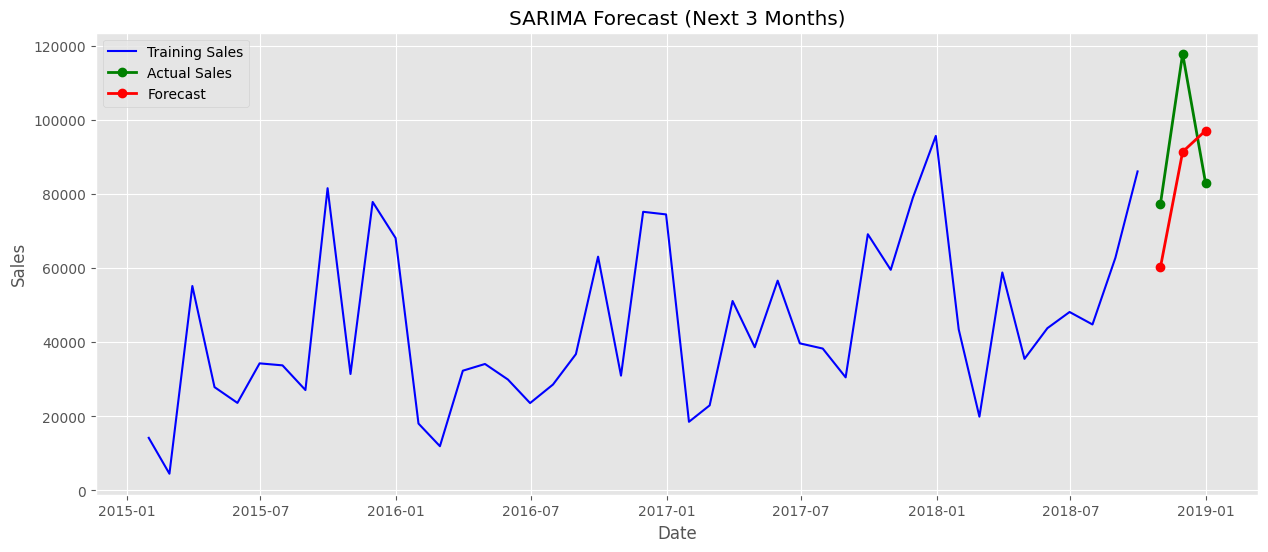

In [54]:
plt.figure(figsize=(15,6))

# Training Data
plt.plot(
    train.index,
    train["Sales"],
    label="Training Sales",
    color="blue"
)

# Actual Test Data
plt.plot(
    test.index,
    test["Sales"],
    marker="o",
    linewidth=2,
    color="green",
    label="Actual Sales"
)

# Forecast
plt.plot(
    test.index,
    forecast,
    marker="o",
    linewidth=2,
    color="red",
    label="Forecast"
)

plt.title("SARIMA Forecast (Next 3 Months)")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# SARIMA Forecast with Confidence Interval

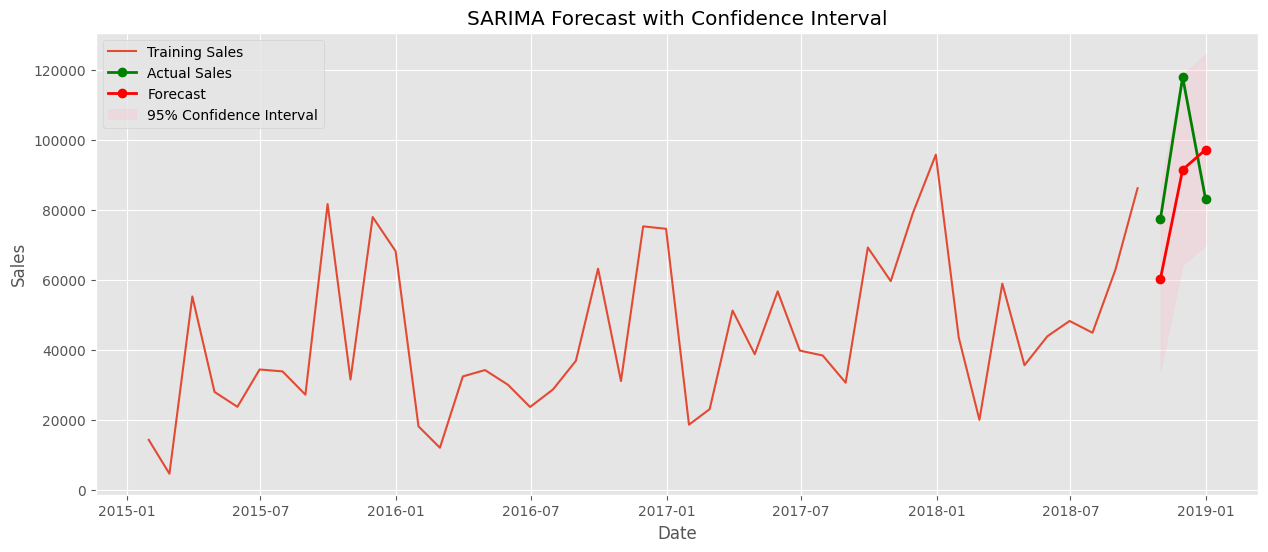

In [55]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Sales"
)

plt.plot(
    test.index,
    test["Sales"],
    color="green",
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    forecast.index,
    forecast,
    color="red",
    marker="o",
    linewidth=2,
    label="Forecast"
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast with Confidence Interval")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [56]:
forecast_df.round(2)

,Actual Sales,Forecast Sales,Lower CI,Upper CI
Order Date,,,,
2018-10-31,77448.13,60331.79,33867.66,86795.92
2018-11-30,117938.16,91458.22,64294.74,118621.70
2018-12-31,83030.39,97167.57,69727.83,124607.31


In [57]:
future_forecast = sarima_result.get_forecast(steps=6)

future_sales = future_forecast.predicted_mean

future_sales.tail(3)

2019-01-31    46856.155415
2019-02-28    37303.503744
2019-03-31    69589.591618
Freq: ME, Name: predicted_mean, dtype: float64

# Future 3 Month Sales Forecast

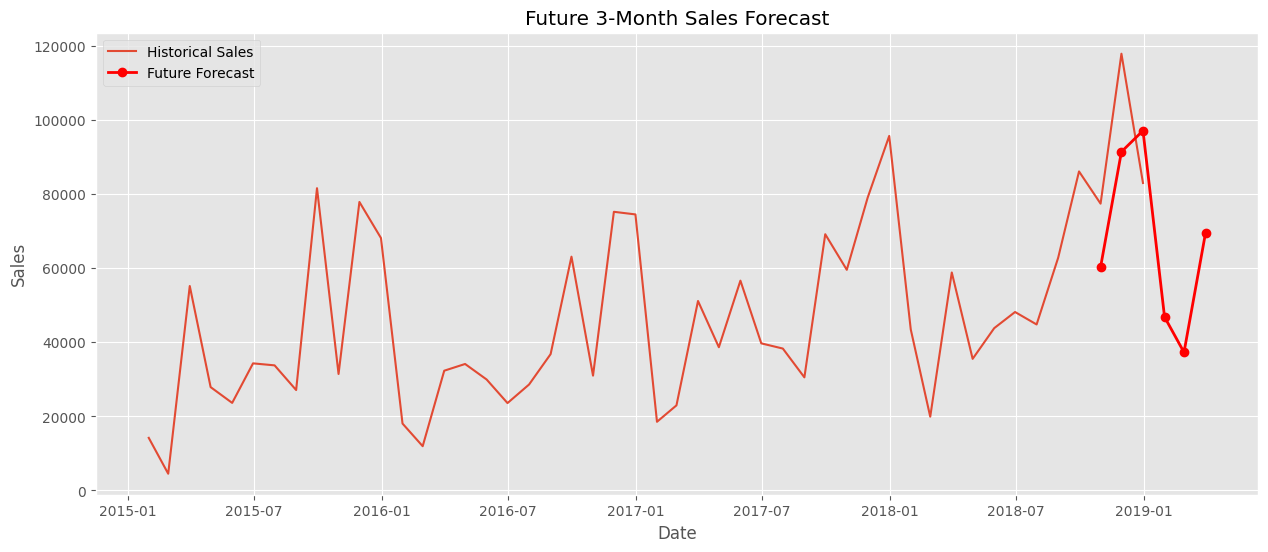

In [58]:
plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_sales.index,
    future_sales,
    color="red",
    linewidth=2,
    marker="o",
    label="Future Forecast"
)

plt.title("Future 3-Month Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [59]:
forecast_df.to_csv(
    "sarima_forecast.csv",
    index=True
)

print("Forecast saved successfully.")

Forecast saved successfully.


In [60]:
# ==========================================
# Import Evaluation Metrics
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# Mean Absolute Error

In [61]:
# Mean Absolute Error

mae = mean_absolute_error(
    test["Sales"],
    forecast
)

print(f"MAE : {mae:.2f}")

MAE : 19244.49


# Root Mean Squared Error

In [62]:
# Root Mean Squared Error

rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        forecast
    )
)

print(f"RMSE : {rmse:.2f}")

RMSE : 19950.07


# Mean Absolute Percentage Error

In [63]:
# Mean Absolute Percentage Error

mape = np.mean(
    np.abs(
        (test["Sales"] - forecast) /
        test["Sales"]
    )
) * 100

print(f"MAPE : {mape:.2f}%")

MAPE : 20.53%


# Metrics Dataset

In [64]:
metrics_df = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "MAPE"
    ],

    "Value":[
        round(mae,2),
        round(rmse,2),
        round(mape,2)
    ]

})

metrics_df

,Metric,Value
0,MAE,19244.49
1,RMSE,19950.07
2,MAPE,20.53


In [65]:
comparison = pd.DataFrame({

    "Actual Sales":test["Sales"],

    "Forecast Sales":forecast

})

comparison["Error"] = (
    comparison["Actual Sales"] -
    comparison["Forecast Sales"]
)

comparison

,Actual Sales,Forecast Sales,Error
2018-10-31,77448.1312,60331.792094,17116.339106
2018-11-30,117938.1550,91458.220223,26479.934777
2018-12-31,83030.3888,97167.570942,-14137.182142


In [66]:
comparison["Percentage Error"] = (

    np.abs(comparison["Error"]) /

    comparison["Actual Sales"]

) * 100

comparison

,Actual Sales,Forecast Sales,Error,Percentage Error
2018-10-31,77448.1312,60331.792094,17116.339106,22.100390
2018-11-30,117938.1550,91458.220223,26479.934777,22.452390
2018-12-31,83030.3888,97167.570942,-14137.182142,17.026516


# Actual vs Forecast Sales

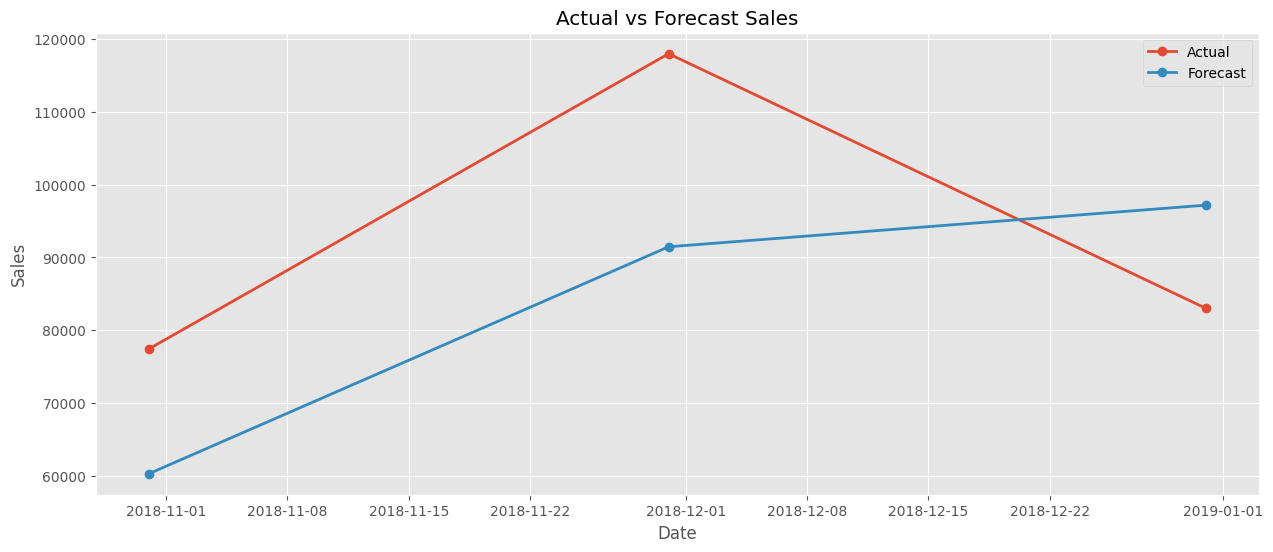

In [67]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison.index,
    comparison["Actual Sales"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    comparison.index,
    comparison["Forecast Sales"],
    marker="o",
    linewidth=2,
    label="Forecast"
)

plt.title("Actual vs Forecast Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# Forecast Error Distribution

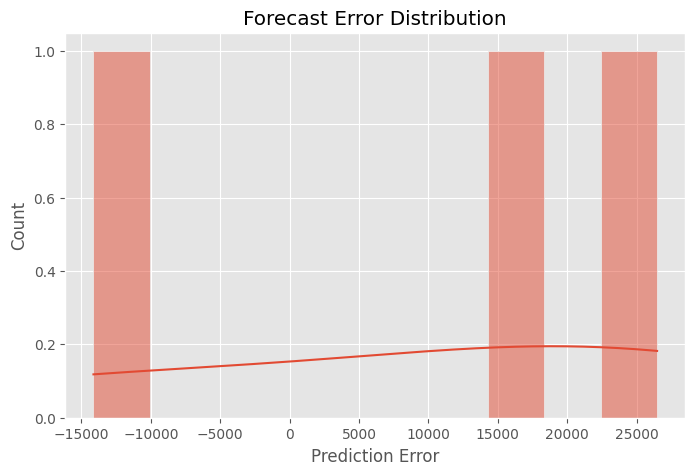

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    comparison["Error"],
    bins=10,
    kde=True
)

plt.title("Forecast Error Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [69]:
comparison.to_csv(
    "sarima_prediction_results.csv"
)

metrics_df.to_csv(
    "sarima_metrics.csv",
    index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.


In [70]:
sarima_summary = pd.DataFrame({

    "Model":["SARIMA"],

    "MAE":[round(mae,2)],

    "RMSE":[round(rmse,2)],

    "MAPE":[round(mape,2)]

})

sarima_summary

,Model,MAE,RMSE,MAPE
0,SARIMA,19244.49,19950.07,20.53


In [71]:
sarima_summary.to_csv(
    "sarima_summary.csv",
    index=False
)